**<font size="6" color="red">ch2. 한글 형태소 분석</font>**
# 1. 자연어처리
- 자연어 : 일상적인 언어
- 자연어 처리 분야:
    * 자연어 이해 : 형태소분석 -> postagging -> 의미분석, 시각화
    * 자연어 생성 : RNN, LSTM, GRU, ... , encoder-decoder알고리즘 -> 트랜스포머알고리즘
- 활용분야 : 트랜드분석, 탐색적 분석, 맞춤법검사, 번역기, 쳇봇

# 2. 자연어 이해 처리 절차
- 전처리 : 단어, 어절 추출
- 분석 후보 생성 : 형태소 분리, 품사태깅(pos tagging)
- 제약조건(불용어 처리) : 규칙 확인
- 분석 : 시각화(워드클라우드), 연관분석, RNN, LSTM, GRU, ...

# 3. 한글형태소 분석 엔진(Konlpy,...)
- 공통기능 : morphs(형태소 나누기), nouns(명사추출), pos(형태소로 나누어 품사 태그)

- Konlpy (pip install konlpy : jpype1라이브러를 의존)
    * HanNanum : 자바로 만든 형태소 분석기(JAVA_HOME 시스템환경변수, Path설정)
    * Kkma     : 자바로 만든 형태소 분석기(JAVA_HOME 시스템환경변수, Path설정)
    * Komoran  : 자바로 만든 형태소 분석기(JAVA_HOME 시스템환경변수, Path설정)
    * Okt
- Mecab (pip install python-mecab-ko)
    * MeCab : C++로 만든 형태소 분석기. 저사양환경에서 사용 가능. 다국어 바인딩 지원

In [3]:
import os
os.environ.get('JAVA_HOME')

'C:\\Program Files\\Java\\jdk-17'

In [4]:
os.environ

environ{'ALLUSERSPROFILE': 'C:\\ProgramData',
        'APPDATA': 'C:\\Users\\Admin\\AppData\\Roaming',
        'APPLICATION_INSIGHTS_NO_STATSBEAT': 'true',
        'CHROME_CRASHPAD_PIPE_NAME': '\\\\.\\pipe\\crashpad_3000_KNEHOZSRGAHVCDKD',
        'COMMONPROGRAMFILES': 'C:\\Program Files\\Common Files',
        'COMMONPROGRAMFILES(X86)': 'C:\\Program Files (x86)\\Common Files',
        'COMMONPROGRAMW6432': 'C:\\Program Files\\Common Files',
        'COMPUTERNAME': 'DESKTOP-HM2OFO1',
        'COMSPEC': 'C:\\Windows\\system32\\cmd.exe',
        'CONDA_DEFAULT_ENV': 'ml-dl-nlp',
        'CONDA_EXE': 'C:\\Users\\Admin\\anaconda3\\Scripts\\conda.exe',
        'CONDA_EXES': '"C:\\Users\\Admin\\anaconda3\\condabin\\..\\Scripts\\conda.exe"  ',
        'CONDA_PREFIX': 'C:\\Users\\Admin\\anaconda3\\envs\\ml-dl-nlp',
        'CONDA_PROMPT_MODIFIER': '(ml-dl-nlp) ',
        'CONDA_PYTHON_EXE': 'C:\\Users\\Admin\\anaconda3\\python.exe',
        'CONDA_ROOT': 'C:\\Users\\Admin\\anaconda3',
        

In [5]:
text = '''아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로
많이 사용되는 언어입니다
'''

## 3.1 HanNanum

In [6]:
from konlpy.tag import Hannanum
hannanum = Hannanum(jvmpath=None,
                    max_heap_size=1024) # 기본값 : 1024
hannanum.analyze(text)

[[[('아름답', 'paa'), ('지만', 'ecs')],
  [('아름답', 'paa'), ('지', 'ecs'), ('만', 'jxc')],
  [('아름답', 'paa'), ('지', 'ecx'), ('말', 'px'), ('ㄴ', 'etm')]],
 [[('다소', 'mag')], [('다소', 'ncn')]],
 [[('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하', 'xsms'), ('기', 'etn'), ('도', 'jxc')]],
 [[('하', 'pvg'), ('ㄴ', 'etm')],
  [('한', 'nnc')],
  [('한', 'ncn')],
  [('한', 'nbn')],
  [('하', 'px'), ('ㄴ', 'etm')]],
 [[('한국어', 'ncn'), ('는', 'jxc')]],
 [[('전세계', 'ncn'), ('에서', 'jca')],
  [('전세', 'ncn'), ('계', 'ncn'), ('에서', 'jca')],
  [('전', 'xp'), ('세계', 'ncn'), ('에서', 'jca')]],
 [[('13', 'nnc'), ('번', 'nbu'), ('째', 'xsnu'), ('로', 'jca')]],
 [],
 [[('많', 'paa'), ('이', 'xsa')], [('많이', 'mag')]],
 [[('사용', 'ncpa'), ('되', 'xsvn'), ('는', 'etm')]],
 [[('언어', 'ncn'), ('이', 'jp'), ('ㅂ니다', 'ef')]]]

- 구글에서 konlpy docs 검색후 https://konlpy.org/
- api 메뉴 -> "Comparison between POS tagging classes"클릭 -> Korean POS tags comparison chart클릭

In [7]:
# 형태소 분석 : morphs
print(hannanum.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '하', 'ㄴ', '한국어', '는', '전세계', '에서', '13번', '째', '로', '많', '이', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [8]:
# 명사만 추출
print(hannanum.nouns(text))

['복잡', '한국어', '전세계', '13번', '사용', '언어']


In [9]:
# 품사태그
print(hannanum.pos(text, ntags=9)) # 품사갯수 기본값 ntags=9

[('아름답', 'P'), ('지만', 'E'), ('다소', 'M'), ('복잡', 'N'), ('하', 'X'), ('기', 'E'), ('도', 'J'), ('하', 'P'), ('ㄴ', 'E'), ('한국어', 'N'), ('는', 'J'), ('전세계', 'N'), ('에서', 'J'), ('13번', 'N'), ('째', 'X'), ('로', 'J'), ('많', 'P'), ('이', 'X'), ('사용', 'N'), ('되', 'X'), ('는', 'E'), ('언어', 'N'), ('이', 'J'), ('ㅂ니다', 'E')]


In [10]:
print(hannanum.pos(text, ntags=22))

[('아름답', 'PA'), ('지만', 'EC'), ('다소', 'MA'), ('복잡', 'NC'), ('하', 'XS'), ('기', 'ET'), ('도', 'JX'), ('하', 'PV'), ('ㄴ', 'ET'), ('한국어', 'NC'), ('는', 'JX'), ('전세계', 'NC'), ('에서', 'JC'), ('13', 'NN'), ('번', 'NB'), ('째', 'XS'), ('로', 'JC'), ('많', 'PA'), ('이', 'XS'), ('사용', 'NC'), ('되', 'XS'), ('는', 'ET'), ('언어', 'NC'), ('이', 'JP'), ('ㅂ니다', 'EF')]


In [11]:
# 퀴즈1. text에서 형용사(PA)만 추출
tagged_text = hannanum.pos(text,ntags=22)
words=[token for token , tag in tagged_text if tag=='PA']
# for token, tag in tagged_text:
#     if tag=='PA':
#         word.append(token)
words

['아름답', '많']

In [12]:
# 퀴즈2 : text에서 명사(NC, NQ, NB, NN, NP)만 추출
print([token for token, tag in tagged_text if tag.find('N')!=-1 ])
print([token for token, tag in tagged_text if (tag=='NC') |
                                              (tag=='NQ') |
                                              (tag=='NB') |
                                              (tag=='NN') |
                                              (tag=='NP')])
print([(token, tag) for token, tag in tagged_text \
               if tag in ('NC', 'NQ', 'NB', 'NN', 'NP') ] )
print(hannanum.nouns(text))

['복잡', '한국어', '전세계', '13', '번', '사용', '언어']
['복잡', '한국어', '전세계', '13', '번', '사용', '언어']
[('복잡', 'NC'), ('한국어', 'NC'), ('전세계', 'NC'), ('13', 'NN'), ('번', 'NB'), ('사용', 'NC'), ('언어', 'NC')]
['복잡', '한국어', '전세계', '13번', '사용', '언어']


In [13]:
# 퀴즈3: text에서 보통명사(NC)만 추출
[token for token, tag in tagged_text if tag=='NC']

['복잡', '한국어', '전세계', '사용', '언어']

## 3.2 Kkma

In [14]:
from konlpy.tag import Kkma
kkma = Kkma(jvmpath=None,
            max_heap_size=1024) # "4m", "4g"
print(kkma.morphs(text)) # 형태소 분석

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전세계', '에서', '13', '번째', '로', '많이', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [15]:
# 명사추출
print(kkma.nouns(text))

['복잡', '한국어', '전세계', '13', '13번째', '번째', '사용', '언어']


In [16]:
# 품사 태깅
print(kkma.pos(text)) # ntags 지정 불가(무조건 56으로)

[('아름답', 'VA'), ('지만', 'ECE'), ('다소', 'MAG'), ('복잡', 'NNG'), ('하', 'XSV'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MDN'), ('한국어', 'NNG'), ('는', 'JX'), ('전세계', 'NNG'), ('에서', 'JKM'), ('13', 'NR'), ('번째', 'NNB'), ('로', 'JKM'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETD'), ('언어', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EFN')]


In [17]:
# 명사 추출
tagged_text = kkma.pos(text)
print([word for word, tag in tagged_text if tag in ('NNG', 'NNP', 'NNB', 'NNM')])
print(kkma.nouns(text))

['복잡', '한국어', '전세계', '번째', '사용', '언어']
['복잡', '한국어', '전세계', '13', '13번째', '번째', '사용', '언어']


In [18]:
# 보통명사(NNG) + 고유명사(NNP)
print([word for word , tag in tagged_text if tag in ('NNG','NNP')])

['복잡', '한국어', '전세계', '사용', '언어']


## 3.3 Komoran

In [19]:
from konlpy.tag import Komoran
komoran = Komoran() # max_heap_size=1024
# 형태소 분석
print(komoran.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [20]:
# 명사 추출
print(komoran.nouns(text))

['한국어', '전', '세계', '번', '사용', '언어']


In [21]:
# 품사 태깅
print(komoran.pos(text)) # ntags 조정 불가

[('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MM'), ('한국어', 'NNP'), ('는', 'JX'), ('전', 'NNG'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNB'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EC')]


In [22]:
# 일반명사(NNG), 고유명사(NNP)만 추출
[token for token, tag in komoran.pos(text) if tag in ('NNG','NNP')]

['한국어', '전', '세계', '사용', '언어']

## 3.4 Twitter( Okt ; Open Korean Text)
- konlpy v0.4.5부터 Twitter-> Okt로 바뀜

In [23]:
import konlpy
konlpy.__version__

'0.6.0'

In [24]:
from konlpy.tag import Twitter, Okt
# okt = Twitter()
okt = Okt() # max_heap_size
print('구 추출 :', okt.phrases(text))
print('형태소 추출 :', okt.morphs(text))
print('명사 추출 :', okt.nouns(text))
tagged_text = okt.pos(text)
print('품사 태깅을 이용한 명사 추출 :',
     [token for token, tag in tagged_text if tag=='Noun']
     )
print('품사 태깅 :', tagged_text)

구 추출 : ['다소', '한국어', '전세계', '13번째', '사용', '사용되는 언어', '13', '번째', '언어']
형태소 추출 : ['아름답지만', '다소', '복잡하기도', '한', '한국어', '는', '전세계', '에서', '13', '번', '째', '로', '\n', '많이', '사용', '되는', '언어', '입니다', '\n']
명사 추출 : ['다소', '한국어', '전세계', '번', '사용', '언어']
품사 태깅을 이용한 명사 추출 : ['다소', '한국어', '전세계', '번', '사용', '언어']
품사 태깅 : [('아름답지만', 'Adjective'), ('다소', 'Noun'), ('복잡하기도', 'Adjective'), ('한', 'Verb'), ('한국어', 'Noun'), ('는', 'Josa'), ('전세계', 'Noun'), ('에서', 'Josa'), ('13', 'Number'), ('번', 'Noun'), ('째', 'Suffix'), ('로', 'Josa'), ('\n', 'Foreign'), ('많이', 'Adverb'), ('사용', 'Noun'), ('되는', 'Verb'), ('언어', 'Noun'), ('입니다', 'Adjective'), ('\n', 'Foreign')]


## 3.5 MeCab
- pip install python-mecab-ko

In [25]:
%%time
from mecab import MeCab
mecab = MeCab() # 힙메모리 사이즈 지정이 안 됨
print('형태소 추출 :', mecab.morphs(text))
print('명사 추출 :', mecab.nouns(text))
tagged_text = mecab.pos(text) # ntags 조정 불가 (ntags=43 고정)
print('품사 태깅을 이용한 명사 추출 :',
    [token for token, tag in tagged_text \
     if tag in ('NNG','NNP','NNB','NNBC','NR','NP')]
     )
print('품사태깅 :', tagged_text)

형태소 추출 : ['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '입니다']
명사 추출 : ['한국어', '세계', '번', '사용', '언어']
품사 태깅을 이용한 명사 추출 : ['한국어', '세계', '번', '사용', '언어']
품사태깅 : [('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MM'), ('한국어', 'NNG'), ('는', 'JX'), ('전', 'MM'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNBC'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('입니다', 'VCP+EC')]
CPU times: total: 312 ms
Wall time: 62.8 ms


# 4. 말뭉치

In [26]:
# 영어 말뭉치
import nltk
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')

In [27]:
%pip show konlpy

Name: konlpy
Version: 0.6.0
Summary: Python package for Korean natural language processing.
Home-page: http://konlpy.org
Author: Team KoNLPy
Author-email: konlpy@googlegroups.com
License: GPL v3
Location: c:\users\admin\anaconda3\envs\ml-dl-nlp\lib\site-packages
Requires: JPype1, lxml, numpy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [28]:
# 한글 말뭉치
from konlpy.corpus import kolaw
#data = kolaw.open('constitution.txt').readlines() # 한줄씩 list로 반환
data = kolaw.open('constitution.txt').read()
print('글자수 :', len(data))
print('%r' % data[:100])

글자수 : 18884
'대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임시정부의 법통과 불의에 항거한 4·19민주이념을 계승하고, 조국의 민주개혁과 평화적 통일의'


# 5. 워드 클라우드
- pip install wordcloud

In [29]:
l = ['aaa', 'bbb', 'ccc', 'aaa']
' '.join(l)

'aaa bbb ccc aaa'

In [30]:
# 말뭉치에서 단어추출(특수 문자 제외)
from nltk.tokenize import RegexpTokenizer
from nltk.tag      import pos_tag
ret = RegexpTokenizer('[\w]{2,}')
words = ret.tokenize(emma)
# 명사(고유명사제외)만 추출
emma_tags = pos_tag(words)
noun_list = [token for token, tag in emma_tags if tag in ('NN', 'NNS')]
print('추출된 명사 갯수 :',len(noun_list), '\t단어 종류수 :',len(set(noun_list)))
print('noun_list :', noun_list[:10])
emma_noun = ' '.join(noun_list)
print('워드 클라우드에 필요한 내용 :', emma_noun[:100])

추출된 명사 갯수 : 22362 	단어 종류수 : 3498
noun_list : ['Emma', 'clever', 'home', 'disposition', 'blessings', 'existence', 'years', 'world', 'daughters', 'indulgent']
워드 클라우드에 필요한 내용 : Emma clever home disposition blessings existence years world daughters indulgent father consequence 


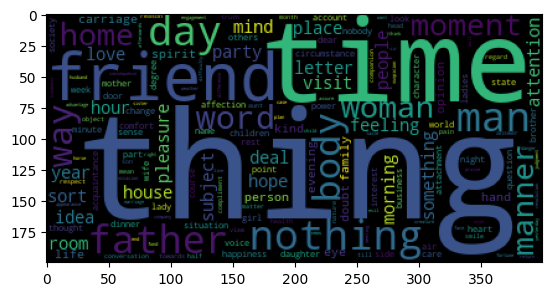

In [31]:
from wordcloud import WordCloud
from matplotlib import pyplot as plt
wordc = WordCloud()
wordc.generate(emma_noun)
plt.imshow(wordc)
plt.show()

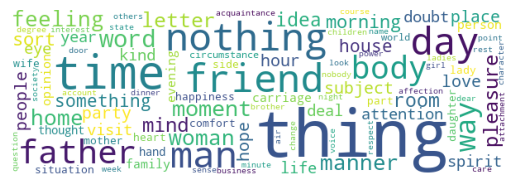

In [35]:
wordcloud = WordCloud(# font_path='',
                    width=600, # 생성될 이미지 가로(픽셀)
                    background_color='white', # 배경색
                    max_words=300, # 표시될 단어의 최대갯수
                    relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                    colormap='viridis', # 글씨 컬러맵
                    max_font_size=80, #최대 폰트 사이즈
                    min_font_size=10  #최소 사이즈
)
wordcloud.generate(emma_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [37]:
# 한글 말뭉치 data로 워드클라우드 시각화
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab      import MeCab
hannanum = Hannanum()